# Morales2018

https://doi.org/10.1111/pce.13119

This notebook validates the Morales et al. (2018) dynamic photosynthesis model implemented in `mxlmodels` against manuscript Figure 6. The analysis compares measured and simulated lightfleck-use efficiency (LFUE) for six Arabidopsis genotypes at lightfleck amplitudes of 100, 200, and 500 μmol m⁻² s⁻¹.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
from mxlpy import Simulator

from mxlmodels import get_morales2018


## Figure 6 reference data

The validation uses the authors' lightfleck measurements, light-response-curve results, and fitted literature and experimental parameters. The four CSV files are exported directly from the corresponding data objects supplied with the original model.

In [2]:
data_candidates = [
    Path("assets"),
    Path("docs/assets"),
]

DATA = next(
    path
    for path in data_candidates
    if (path / "lightflecks_mean.csv").exists()
)

print("Using validation data from:", DATA.resolve())

lightflecks = pd.read_csv(DATA / "lightflecks_mean.csv")
lrc = pd.read_csv(DATA / "LRC.csv")
parameters_literature = pd.read_csv(DATA / "ParametersLiterature.csv").set_index("parameter")
parameters_experiment = pd.read_csv(DATA / "ParametersExperiment.csv").set_index("parameter")

genotypes = ["col", "npq1", "npq4", "rca2", "rwt43", "spsa"]
amplitudes = [100, 200, 500]

steady_state_reference = pd.read_csv(
    DATA / "steady_state_reference.csv"
)


Using validation data from: C:\Users\malik\OneDrive\Desktop\mxl-models\docs\assets


## Figure 6 parameterisation

Experimental parameter estimates replace the corresponding literature values, following the original `Validation.R` workflow. Values are converted to the internal SI units used by the MxlPy implementation. Mutant-specific values are applied only to their respective genotype simulations.

In [3]:
parameters = parameters_literature.copy()
for name, row in parameters_experiment.iterrows():
    parameters.loc[name, ["value", "lower", "upper"]] = row[["value", "lower", "upper"]]

mutant_names = [
    "TPU25_spsa",
    "RCA_rca2",
    "Jmax25_rca2",
    "Jmax25_npq4",
    "Jmax25_rwt43",
]
mutant_parameters = parameters.loc[mutant_names, "value"].to_dict()
parameters = parameters.drop(index=mutant_names, errors="ignore")
parameters.loc["gamma3", "value"] = (
    1.0 - parameters.loc["gamma1", "value"] - parameters.loc["gamma2", "value"]
)

micro = {
    "Jmax25", "Iac", "Vrmax", "KmPGA", "RB", "Kmc25", "Vch",
    "TPU25", "Rm25", "volume_chamber", "Flow",
}
mega = {
    "DHaJmax", "DHdJmax", "DsJmax", "Kinh0", "fprot", "DHaKrep",
    "DHdKrep", "DsKrep", "alphar_alpha25", "DHaAlphar", "DHaKalpha",
    "DsKalpha", "DHdKalpha", "alphafR", "DHaKc", "DHaKo", "DHaKmc",
    "DHaKmo", "bc", "DHdRCA", "DHaRCA", "DHaTPU", "DHdTPU",
    "DsTPU", "DHaGc", "DHdGc", "DsGc", "DHaGw", "DHdGw", "DsGw",
    "DHaRm", "D0", "alphafI",
}
milli = {"Kmo25", "KaRCA", "O2", "RCA"}


def convert_parameter(name, value):
    if name in micro:
        return value * 1e-6
    if name in mega:
        return value * 1e6
    if name in milli:
        return value * 1e-3
    if name == "Krca":
        return value * 1e3
    if name == "leaf_surface":
        return value * 1e-4
    return value


base_parameters = {
    name: convert_parameter(name, value)
    for name, value in parameters["value"].items()
}


## Genotype-specific models

The `npq1`, `npq4`, `rca2`, and `spsa` variants use the parameter substitutions defined in the original validation. The `rwt43` variant additionally replaces the RuBP-regeneration-dependent Rubisco activation target with the light-dependent rule used in the authors' compiled `MiniModelrwt43` model.

In [4]:
flux0 = 1e-22


def frbss_r_rwt43(par, frb_min, frb_max):
    return frb_max if par > flux0 else frb_min


def make_genotype_model(genotype):
    model = get_morales2018()
    available = set(model.get_parameter_names())
    model.update_parameters(
        {name: value for name, value in base_parameters.items() if name in available}
    )

    if genotype == "rca2":
        model.update_parameters(
            {
                "RCA": convert_parameter("RCA", mutant_parameters["RCA_rca2"]),
                "Jmax25": convert_parameter(
                    "Jmax25", mutant_parameters["Jmax25_rca2"]
                ),
            }
        )
    elif genotype == "spsa":
        model.update_parameter(
            "TPU25", convert_parameter("TPU25", mutant_parameters["TPU25_spsa"])
        )
    elif genotype == "npq4":
        model.update_parameters(
            {
                "Jmax25": convert_parameter(
                    "Jmax25", mutant_parameters["Jmax25_npq4"]
                ),
                "KiqEp": 0.0,
            }
        )
    elif genotype == "npq1":
        model.update_parameter("KiqEz", 0.0)
    elif genotype == "rwt43":
        model.update_parameter(
            "Jmax25",
            convert_parameter("Jmax25", mutant_parameters["Jmax25_rwt43"]),
        )
        model.update_derived(
            "fRBss_r",
            fn=frbss_r_rwt43,
            args=["PAR", "fRBmin", "fRBmax"],
        )

    return model


## Simulate the Figure 6 lightflecks

Each genotype-amplitude combination is acclimated for 7200 s under its initial measured conditions. The acclimated state is then simulated using the measured PAR, humidity, CO₂, air-temperature, and leaf-temperature trajectories. PAR is supplied through the modifiable light-input parameters `Ib`, `Ig`, and `Ir`, retaining the original 10:0:90 blue:green:red composition.

In [5]:
def forcing_values(row):
    par = float(row["PAR"])
    return {
        "Ib": par * 0.10e-6,
        "Ig": 0.0,
        "Ir": par * 0.90e-6,
        "H2OR": float(row["H2OR"]) * 1e-3,
        "CO2R": float(row["CO2R"]) * 1e-6,
        "Ta": float(row["Tair"]),
        "Tl": float(row["Tleaf"]),
    }


def simulate_lightfleck(genotype, amplitude):
    data = (
        lightflecks[
            (lightflecks["Genotype"] == genotype)
            & (lightflecks["Amplitude"] == amplitude)
            & (lightflecks["Obs"] <= 1262)
        ]
        .sort_values("Obs")
        .reset_index(drop=True)
    )
    if len(data) != 1262:
        raise ValueError(
            f"{genotype}, amplitude {amplitude}: expected 1262 rows, found {len(data)}"
        )

    model = make_genotype_model(genotype)
    initial_forcing = forcing_values(data.iloc[0])
    model.update_parameters(initial_forcing)

    y0 = model.get_initial_conditions()
    y0.update(
        {
            "Ci": initial_forcing["CO2R"],
            "Cc": initial_forcing["CO2R"],
            "Ccyt": initial_forcing["CO2R"],
            "PR": 100e-6,
        }
    )
    if genotype == "npq4":
        y0["fP"] = 0.0
    elif genotype == "npq1":
        y0["fZ"] = 0.0

    acclimation = Simulator(model, y0=y0)
    acclimation.simulate(7200, steps=2)
    adapted_y0 = (
        acclimation.get_result()
        .unwrap_or_err()
        .variables.iloc[-1]
        .to_dict()
    )

    experiment = data.iloc[2:].copy()
    experiment["simulation_time"] = experiment["Time"] - 3600.0
    experiment_time = experiment["simulation_time"].to_numpy()

    forcing_rows = [
        forcing_values(row) for _, row in experiment.iterrows()
    ]

    # mxlpy applies each protocol row over the interval ending at its index.
    # Shift values so the interval uses forcing from its starting point.
    protocol_values = [forcing_rows[0], *forcing_rows[:-1]]

    protocol = pd.DataFrame(
        protocol_values,
        index=pd.to_timedelta(experiment_time + 1e-6, unit="s"),
    )
    protocol.index.name = "Timedelta"

    simulator = Simulator(model, y0=adapted_y0)
    simulator.simulate_protocol_time_course(
        protocol=protocol,
        time_points=experiment_time,
    )
    result = simulator.get_result().unwrap_or_err().get_combined()
    simulated = result.reindex(experiment_time)

    output = experiment.reset_index(drop=True)
    output["simAn"] = simulated["A"].to_numpy() * 1e6
    output["simPhoto"] = simulated["Photo"].to_numpy() * 1e6
    return output


simulation_outputs = []

for genotype in genotypes:
    for amplitude in amplitudes:
        print(f"Simulating {genotype}, amplitude {amplitude}")

        with warnings.catch_warnings():
            warnings.filterwarnings(
                "ignore",
                message="divide by zero encountered in scalar divide",
                category=RuntimeWarning,
            )
            result = simulate_lightfleck(genotype, amplitude)

        simulation_outputs.append(result)

lf = pd.concat(simulation_outputs, ignore_index=True)


Simulating col, amplitude 100
Simulating col, amplitude 200
Simulating col, amplitude 500
Simulating npq1, amplitude 100
Simulating npq1, amplitude 200
Simulating npq1, amplitude 500
Simulating npq4, amplitude 100
Simulating npq4, amplitude 200
Simulating npq4, amplitude 500
Simulating rca2, amplitude 100
Simulating rca2, amplitude 200
Simulating rca2, amplitude 500
Simulating rwt43, amplitude 100
Simulating rwt43, amplitude 200
Simulating rwt43, amplitude 500
Simulating spsa, amplitude 100
Simulating spsa, amplitude 200
Simulating spsa, amplitude 500


## Calculate LFUE

Whole-cycle and half-cycle LFUE are calculated as the mean dynamic photosynthetic rate divided by the genotype-specific steady-state rate. Steady-state rates are obtained from local quadratic regressions of the supplied light-response curves, following the original R analysis.

In [6]:
def add_period_information(group):
    group = group.copy().reset_index(drop=True)
    group["Period"] = np.concatenate(
        [np.full(60, -1), np.full(600, 120), np.full(600, 60)]
    )
    direction = np.empty(1260, dtype=object)
    direction[:60] = None
    direction[60:660] = np.tile(np.repeat(["up", "down"], 60), 5)
    direction[660:] = np.tile(np.repeat(["up", "down"], 30), 10)
    group["Direction"] = direction
    return group

lf = pd.concat(simulation_outputs, ignore_index=True)
period_outputs = []

for (genotype, amplitude), group in lf.groupby(
    ["Genotype", "Amplitude"]
):
    enriched = add_period_information(group)
    enriched["Genotype"] = genotype
    enriched["Amplitude"] = amplitude
    period_outputs.append(enriched)

lf = pd.concat(period_outputs, ignore_index=True)


# Use the exact steady-state LOESS predictions produced by the
# original R analysis. Rounding provides a stable floating-point key.
lf["_PAR_key"] = lf["PAR"].round(8)

steady_state_reference = steady_state_reference.copy()
steady_state_reference["_PAR_key"] = (
    steady_state_reference["PAR"].round(8)
)

lf = lf.merge(
    steady_state_reference[
        ["Genotype", "_PAR_key", "Photoss", "simPhotoss"]
    ],
    on=["Genotype", "_PAR_key"],
    how="left",
    validate="many_to_one",
)

lf = lf.drop(columns="_PAR_key")

if lf[["Photoss", "simPhotoss"]].isna().any().any():
    missing = lf.loc[
        lf["Photoss"].isna() | lf["simPhotoss"].isna(),
        ["Genotype", "PAR"],
    ].drop_duplicates()
    raise ValueError(
        "Missing steady-state reference values:\n"
        + missing.to_string(index=False)
    )
lf_positive = lf[lf["Period"] > 0].copy()


def whole_cycle_summary(group):
    return pd.Series(
        {
            "LFUE": group["Photo"].mean() / group["Photoss"].mean(),
            "simLFUE": group["simPhoto"].mean() / group["simPhotoss"].mean(),
            "simLFUEAn": group["simAn"].mean() / group["simPhotoss"].mean(),
        }
    )


def half_cycle_summary(group):
    return pd.Series(
        {
            "LFUE": group["Photo"].mean() / group["Photoss"].mean(),
            "simLFUE": group["simPhoto"].mean() / group["simPhotoss"].mean(),
        }
    )


LFUE = (
    lf_positive.groupby(["Genotype", "Amplitude", "Period"])
    .apply(whole_cycle_summary)
    .reset_index()
)
LFUEcycle = (
    lf_positive.groupby(["Genotype", "Amplitude", "Period", "Direction"])
    .apply(half_cycle_summary)
    .reset_index()
)


## Figure 6 reproduction

Panels A–C compare measured and simulated LFUE for whole cycles, increasing-light half cycles, and decreasing-light half cycles. Genotype labels follow the underlying simulation identifiers; this corrects the reversed `rca2` and `rwt43` labels in the original plotting script.

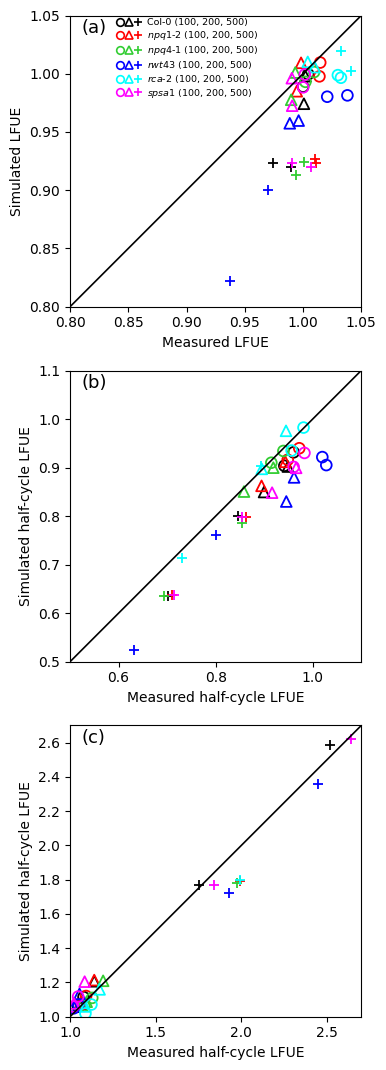

In [7]:
colors = {
    "col": "black",
    "npq1": "red",
    "npq4": "limegreen",
    "rca2": "blue",
    "rwt43": "cyan",
    "spsa": "magenta",
}
labels = {
    "col": "Col-0 (100, 200, 500)",
    "npq1": r"$npq1$-2 (100, 200, 500)",
    "npq4": r"$npq4$-1 (100, 200, 500)",
    "rca2": r"$rwt43$ (100, 200, 500)",
    "rwt43": r"$rca$-2 (100, 200, 500)",
    "spsa": r"$spsa1$ (100, 200, 500)",
}
markers = {100: "o", 200: "^", 500: "+"}


def plot_points(ax, data):
    for genotype in genotypes:
        for amplitude in amplitudes:
            values = data[
                (data["Genotype"] == genotype)
                & (data["Amplitude"] == amplitude)
            ]
            marker = markers[amplitude]
            kwargs = {
                "marker": marker,
                "s": 60,
                "linewidths": 1.3,
            }
            if marker == "+":
                kwargs["color"] = colors[genotype]
            else:
                kwargs["edgecolors"] = colors[genotype]
                kwargs["facecolors"] = "none"
            ax.scatter(values["LFUE"], values["simLFUE"], **kwargs)


fig, axes = plt.subplots(3, 1, figsize=(4.2, 10.8))

panels = [
    (axes[0], LFUE, (0.8, 1.05), "(a)", "Measured LFUE", "Simulated LFUE"),
    (
        axes[1],
        LFUEcycle[LFUEcycle["Direction"] == "up"],
        (0.5, 1.1),
        "(b)",
        "Measured half-cycle LFUE",
        "Simulated half-cycle LFUE",
    ),
    (
        axes[2],
        LFUEcycle[LFUEcycle["Direction"] == "down"],
        (1.0, 2.7),
        "(c)",
        "Measured half-cycle LFUE",
        "Simulated half-cycle LFUE",
    ),
]

for ax, data, limits, panel, xlabel, ylabel in panels:
    ax.plot(limits, limits, color="black", linewidth=1.2)
    plot_points(ax, data)
    ax.set_xlim(limits)
    ax.set_ylim(limits)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.text(
        limits[0] + 0.04 * (limits[1] - limits[0]),
        limits[1] - 0.06 * (limits[1] - limits[0]),
        panel,
        fontsize=13,
    )
    ax.set_aspect("equal", adjustable="box")
    ax.grid(False)

from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple

legend_handles = []

for genotype in genotypes:
    genotype_handles = tuple(
        Line2D(
            [],
            [],
            linestyle="none",
            marker=markers[amplitude],
            markersize=5.5,
            markeredgewidth=1.2,
            color=colors[genotype],
            markeredgecolor=colors[genotype],
            markerfacecolor=(
                "none" if markers[amplitude] != "+" else colors[genotype]
            ),
        )
        for amplitude in amplitudes
    )
    legend_handles.append(genotype_handles)

axes[0].legend(
    legend_handles,
    [labels[genotype] for genotype in genotypes],
    handler_map={tuple: HandlerTuple(ndivide=None, pad=0.1)},
    loc="upper left",
    bbox_to_anchor=(0.14, 1.01),
    frameon=False,
    fontsize=6.8,
    handlelength=2.7,
    handletextpad=0.5,
    labelspacing=0.2,
    borderaxespad=0.2,
)
plt.tight_layout()
plt.show()


## Quantitative validation

RMSE and modelling efficiency are reported by genotype for all half cycles and separately for increasing- and decreasing-light phases.

In [8]:
def validation_statistics(data):
    return (
        data.groupby("Genotype")
        .apply(
            lambda group: pd.Series(
                {
                    "RMSE": np.std(
                        group["LFUE"] - group["simLFUE"], ddof=1
                    ),
                    "R2_percent": 100
                    * (
                        1
                        - np.var(
                            group["LFUE"] - group["simLFUE"], ddof=1
                        )
                        / np.var(group["LFUE"], ddof=1)
                    ),
                }
            )
        )
    )


stats_total = validation_statistics(LFUEcycle)
stats_up = validation_statistics(
    LFUEcycle[LFUEcycle["Direction"] == "up"]
)
stats_down = validation_statistics(
    LFUEcycle[LFUEcycle["Direction"] == "down"]
)

display(stats_total)
display(stats_up)
display(stats_down)


,RMSE,R2_percent
Genotype,,
col,0.046306,99.134971
npq1,0.076165,98.309463
npq4,0.079150,98.318025
rca2,0.083836,97.274203
rwt43,0.075106,98.406544
spsa,0.067581,98.414653


,RMSE,R2_percent
Genotype,,
col,0.012651,98.332086
npq1,0.019086,96.026219
npq4,0.028606,89.904279
rca2,0.030468,96.077834
rwt43,0.019067,95.477197
spsa,0.008642,99.281953


,RMSE,R2_percent
Genotype,,
col,0.027612,99.784136
npq1,0.111247,97.551721
npq4,0.107362,97.798153
rca2,0.106216,97.031632
rwt43,0.082125,98.696499
spsa,0.066656,99.004234
